# Lab 06 – demo notebook

<span style="color: red;">**Do not read through this notebook until after the Lab 06 invention activity is done in class.**</span>

## 1. Load the libraries and the data to fit

In [1]:
%reset -f
import data_entry2
import numpy as np
import matplotlib.pyplot as plt
import fit_plot

# When exporting to html, first change the False below to True, and then "Restart Kernel and Run All Cells"
fit_plot.set_html_export(False)  

In [2]:
# Load the data used from Prelab 05.
data_entry2.sheet_copy("../../Lab05/prelab05_hookes_law", "demo_data")

Sheet name: demo_data.csv


## 2. Chi-square minimization (also known as *weighted least squares*)

**Chi-square minimization** (or **weighted least squares**) is a method used for finding the **best-fitting parameters** of a model when fitting data.

In the following code, adding the argument `chi2 = True` to `fit_plot.line` enables the `Chi2` output. Please note `fit_plot.line` returns **reduced chi-square** $\chi^2_\mathrm{red}$, as seen in class during the invention activity. 

Try to minimize the value for $\chi^2_\mathrm{red}$ using a combination of clicking within the scatter plot, within the residuals plot, and updating the values manually using the text boxes. You should be able to find a combination of parameters that gets you to a $\chi^2_\mathrm{red}$ value that is slightly below 0.67. You can also check the answer in the cell that follows the fitting widget. 

In [3]:
x_data = DxVec
y_data = FVec
del_x_data = dDxVec
del_y_data = dFVec

unique_graph_title = "Chi-square minimization for Prelab 05 Hook's law data"

# Note that "chi2=True" has been enabled; fit_plot.line now provides chi-squared output
fit_plot.line(unique_graph_title, x_data, y_data, del_y_data, chi2=True)

AppLayout(children=(Canvas(header_visible=False, layout=Layout(grid_area='header'), toolbar=Toolbar(toolitems=…

In [4]:
data_entry2.sheet("chi2_results")

Sheet name: chi2_results.csv


#### Answer: best-fitting model parameters

The best-fitting parameters are `Slope = 2.08` and `Intercept = 0.0045`, which gives a $\chi^2_\mathrm{red}$ of 0.66.

## 3. Estimate the uncertainty in the slope using reduced chi-square

Our new statistic for goodness-of-fit testing, $\chi^2_\mathrm{red}$, allows us to use an improved method to determine the uncertainty in the slope, which we will demonstrate below.

To find `slope_max` and `slope_min`, keep the `Intercept` value **fixed** at the one you found for the best-fitting line, and then adjust the `Slope` up and down (using the text box, not by clicking on the graph) to approximately double the value of $\chi^2_\mathrm{red}$ as compared to the one for the best fit. This provides the 68% Confidence Interval for the slope, which you can divide by 2 to get the standard uncertainty in the slope.

The steps:
1. The best estimate of your slope will be the one from your best-fitting model above with the lowest $\chi^2_\mathrm{red}$. In this example the best-fitting model is `Slope = 2.08 N/m` and `Intercept = 0.0045 m`, which corresponds to a $\chi^2_\mathrm{red}$ of 0.66.
2. While keeping `Intercept` fixed at `0.0045 m`, we adjust `Slope` upward until our chi-squared approximately doubles: $\chi^2_\mathrm{red} \approx 2 \times 0.66 \approx 1.32$. For the purposes of this process, we can say that $``\approx''$ means within 5% of this doubled value, so 1.25 - 1.39. You should find that if you set the slope to 2.148 N/m, you get $\chi^2_\mathrm{red} = 1.33$. Thus we say `slope_max = 2.148 N/m` because this is the slope that doubles our best-fit $\chi^2_\mathrm{red}$. Notice how the residuals for this fit look consistent with how we have described `slope_max` in the past. 
5. Take the slope back to the `best_fit` value of `2.08 N/m` while continuing to keep `Intercept` fixed. Now we adjust the `Slope` downward until it gives a $\chi^2_\mathrm{red}$ of approximately 1.32. Here we find `slope_min = 2.013 N/m` corresponds to $\chi^2_\mathrm{red}$ = 1.32.
6. The best estimate of the standard uncertainty of the slope is half of the difference between `slope_max` and `slope_min` (the 68% Confidence Interval for the slope), where each of these slopes were found by adjusting the `Slope` until $\chi^2_\mathrm{red}$ had approximately doubled. We then apply an additional factor of $1/\sqrt{N-P}$ to include the precision benefits of taking more measurements.

The code below details these calculations.

In [5]:
# Calculate the uncertainty in the slope (all slope values correspond to a fit 
# using intercept = 0.0045 m).

slope_best = 2.08  # Chi2: 0.66
slope_max = 2.15   # Chi2: 1.33 (approximately 2*0.66)
slope_min = 2.013  # Chi2: 1.32 (approximately 2*0.66)

N = len(x_data)
P = 2 # Two fitting parameters: slope and y-intercept

del_slope = (slope_max - slope_min) / (2 * np.sqrt(N-P))

# Print the slope value and the uncertainty in the slope.
print(f"The best-fitting slope is: {slope_best:g} ± {del_slope:g} N/m")

The best-fitting slope is: 2.08 ± 0.0306341 N/m


**Reporting results:** Our best estimate of the slope is 2.080 $\pm$ 0.031 N/m.

## 4. Scatter plot and residual plot with complete $\chi^2_\mathrm{red}$ analysis

Below we provide code to produce a scatter and residuals plots, with a complete reduced chi-squared analysis. Copy the two code cells below into your notebook, but before running them you need to have done the following in **your** notebook:

- **Step 1:** Chi-square minimization to find the best-fitting parameters (Section 2 above), 
- **Step 2:** Estimate the uncertainty in the slope using the reduced chi-square (Section 3 above),
- **Step 3:** Update the user varaiables in your copy of Cell 1 from below so that all of the user variable point to correct data vectors and provide the correct names for graph labels and titles.

This code prints out a handy "FIT REPORT" that you can adapt and use in your analysis/comparison/conclusion parts of your lab notebook.

In [6]:
# LINEAR MODEL + REDUCED CHI-SQUARE ANALYSIS: Cell 1 - User variables

# *** Update these variables for your own analysis***

# Your data vectors
x_data = DxVec
y_data = FVec
del_x_data = dDxVec
del_y_data = dFVec

# Your best slope and y-intecept, with units
m = slope_best # 2.08 from above
b = 0.0045     # From our interaction with fit_plot
m_units = "N/m"
b_units = "N"

# Labels for your plot
data_label = "Data"
graph_title = "Spring data with the best-fitting curve from a linear model"
x_label = "Displacement of spring from equilibrium (m)"
y_label = "Force (N)"

# Your max and min slope, for the FIT REPORT and uncertainty in slope
m_max = slope_max  # 2.15 from above
m_min = slope_min  # 2.013 from above

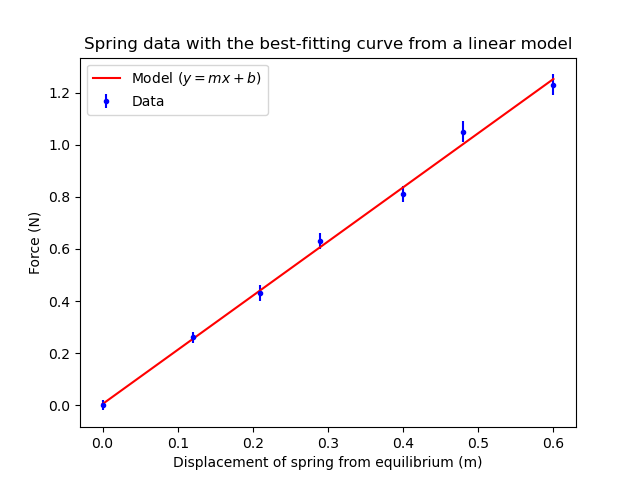

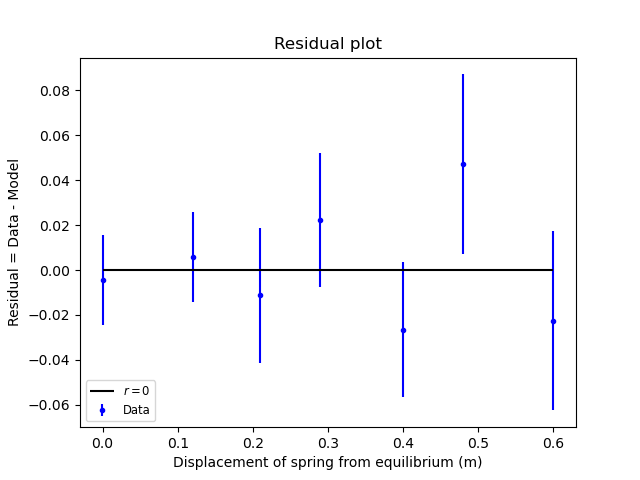

FIT REPORT
[ Model ]
    Linear model: y = mx + b
[ Fit Statistics ]
    • Fitting method : Chi-square minimization
    • Data points    : N = 7
    • Parameters     : P = 2
    Reduced chi-square = 0.66
[ Parameters (best-fitting values) ]
          slope: m = 2.08       ± 0.0306341 N/m   (1.47%)
    y-intercept: b = 0.0045                 N    


In [7]:
# LINEAR MODEL + REDUCED CHI-SQUARE ANALYSIS: Cell 2 - Analysis code

########################################################################################
# Model – step 1: find the range of x values from the experimental data.
########################################################################################

x_min = np.min(x_data)  # find the smallest x value
x_max = np.max(x_data)  # find the largest x value

########################################################################################
# Model – step 2: generate model x values 
########################################################################################

# Generate model x values between x_min and x_max for which we want to plot the model y values.
x_model = np.linspace(start=x_min, stop=x_max, num=200) # return 200 evenly spaced values

########################################################################################
# Model – step 3: calculate the model y values at each of the model x values.
########################################################################################

# Choose best-fitting values for the linear model.
y_model = m * x_model + b

########################################################################################
# Model – step 4: plot the model on the graph of the experimental data.
########################################################################################

# Create a new figure.
fig = plt.figure()

# Generate scatter plot
plt.errorbar(
    x=x_data, y=y_data, yerr=del_y_data,
    fmt='bo', markersize=3, label=data_label
    )  # plot experimental data
plt.title(graph_title)
plt.xlabel(x_label)
plt.ylabel(y_label)
model_label = "Model ($y = mx + b$)"
plt.plot(x_model, y_model, "r-", label=model_label)  # plot model data
# Add a legend (you can change the location as needed)
plt.legend(loc='upper left')

# Show and close our scatter plot
plt.show(fig)
plt.close(fig)

########################################################################################
# Residuals – step 1: calculate the model predictions y_prediction for each of
########################################################################################

# The measured x_data values.
y_prediction = m * x_data + b

########################################################################################
# Residuals – step 2: calculate the residuals.
########################################################################################

residuals = y_data - y_prediction

########################################################################################
# Residuals – step 3: plot the residuals against the measured x_data values.
########################################################################################

# Create a new figure for the residual plot.
fig = plt.figure()

# Generate residual plot
residual_graph_title = "Residual plot"
residual_y_label = "Residual = Data - Model"
plt.errorbar(
    x=x_data, y=residuals, yerr=del_y_data,
    fmt='bo', markersize=3, label=data_label
    )
plt.title(residual_graph_title)
plt.xlabel(x_label)  # reuse the x-label from the scatter plot
plt.ylabel(residual_y_label)

########################################################################################
# Residuals – step 4: add a horizontal line at r=0 to the plot.
########################################################################################

plt.hlines(y=0, xmin=x_min, xmax=x_max, color='k', label="$r = 0$")
# Add a legend (you can change the location as needed)
plt.legend(loc='lower left', fontsize='small')

# Show and close our residuals plot
plt.show(fig)
plt.close(fig)

########################################################################################
# FIT REPORT - Summary of the reduced chi-square analysis.
########################################################################################
# Report the values from your estimate of the uncertainty in the slope using
# the fit_plot.line widget and doubling the reduced chi-square.

# Define the number of fitting parameters ("P" in the reduced chi-square
# formula).
P = 2  # slope and y-intercept
N = len(x_data)

# Calculate the uncertainty in the slope.
del_m = (m_max - m_min) / (2 * np.sqrt(N-P))

# Calculate the reduced chi-square.
reduced_chi_square = 1 / (N - P) * np.sum( (residuals/del_y_data)**2 )

# Advanced code for creating a fit report in Python with the right number of 
# decimals (for the best value) and significant figures (for the uncertainty).
# Note that in the printed report, the number in parentheses next to the
# uncertainty in the slope is the associated relative uncertainty
# (expressed as a percentage).
SIG_FIGS = 2  # constant in our class
print("FIT REPORT")
print("[ Model ]")
print(f"{'':<4}""Linear model: y = mx + b")
print("[ Fit Statistics ]")
print(f"{'':<4}{'• Fitting method':<17}: Chi-square minimization")
print(f"{'':<4}{'• Data points':<17}{': N = ' + str(N):<5}")
print(f"{'':<4}{'• Parameters':<17}{': P = ' + str(P):<5}")
print(f"{'':<4}"f"Reduced chi-square = {reduced_chi_square:.{SIG_FIGS}f}")
print("[ Parameters (best-fitting values) ]")
print(
    f"{'':<4}{'slope: m = ':>17}{m:<10g}{' ± ':<3}"
    f"{del_m:<10g}{m_units:<5} ({del_m / m * 100:.{SIG_FIGS}f}%)"
    )
print(f"{'':<4}{'y-intercept: b = ':>17}{b:<10g}{'':<3}{'':<10}{b_units:<5}")